This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction.

In [1]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#
#import yfinance as yf
#df_HSI = yf.download("^HSI", start="2022-01-01", end="2023-01-01" ).droplevel('Ticker', axis=1)

company = "0005.HK"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070
2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352
2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589
2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355


In [4]:
# Save to CSV
df_HKstock.to_csv('0005.HK260101.csv')

In [5]:
#
df_source = pd.read_csv("0005.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070
2,2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352
3,2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589
4,2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
731,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
732,2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355
733,2025-12-30,118.498833,118.787857,116.764701,116.764701,11747636


In [6]:
#
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070
2,2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352
3,2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589
4,2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
731,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
732,2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355
733,2025-12-30,118.498833,118.787857,116.764701,116.764701,11747636


In [7]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    735 non-null    datetime64[ns]
 1   Close   735 non-null    float64       
 2   High    735 non-null    float64       
 3   Low     735 non-null    float64       
 4   Open    735 non-null    float64       
 5   Volume  735 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.6 KB


In [8]:
df_source = df_source.set_index('Date', )     # set Date as index
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 735 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   735 non-null    float64
 1   High    735 non-null    float64
 2   Low     735 non-null    float64
 3   Open    735 non-null    float64
 4   Volume  735 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [9]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070
2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352
2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589
2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355


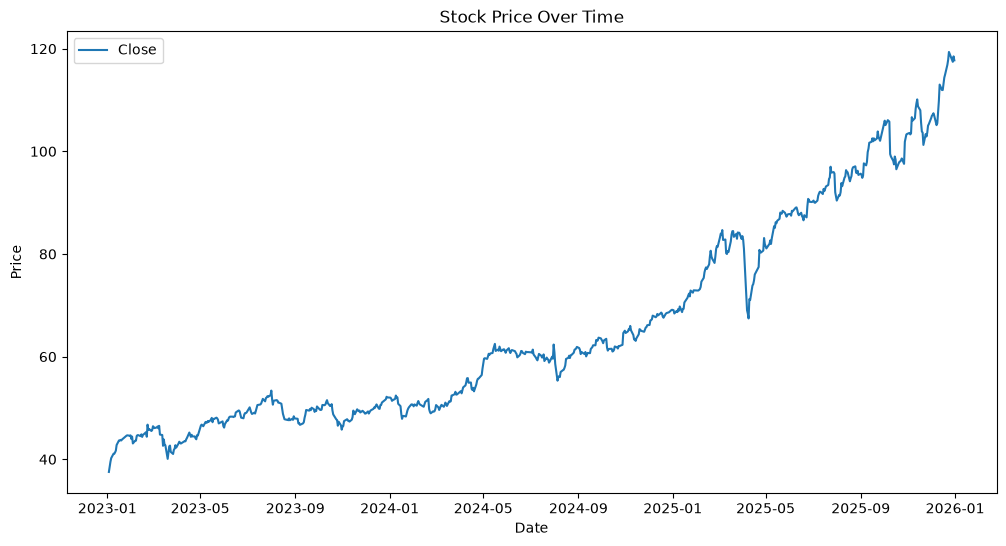

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

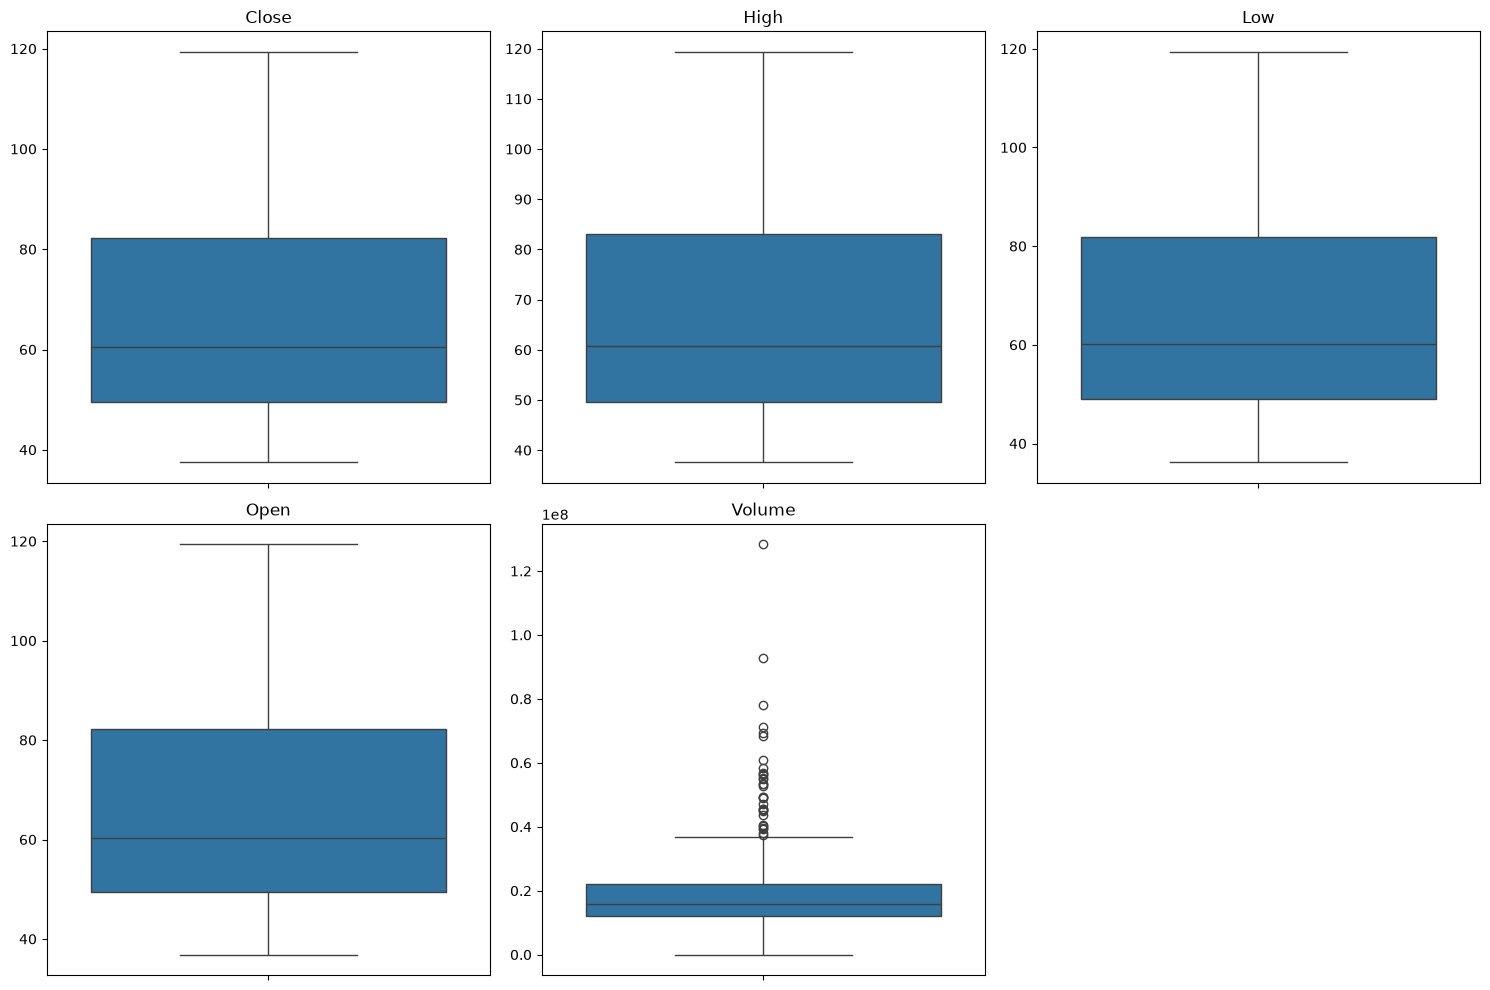

In [11]:
# Check outliers and variations
#import math
#import matplotlib.pyplot as plt
#import seaborn as sns
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

Box plots apply to identify outliers; may identify anomalous trading days or incorrect data points

In [12]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [13]:
# Handling if missing values
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070
2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352
2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589
2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355


In [14]:
# Calculate moving averages and daily returns
df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [15]:
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602,NaN,NaN,NaN
2023-01-04,38.540058,38.540058,38.039036,38.116118,20526070,NaN,NaN,0.026694
2023-01-05,39.503559,39.619180,39.118159,39.310859,29598352,NaN,NaN,0.025000
2023-01-06,40.235832,40.582693,40.043132,40.428533,30945589,NaN,NaN,0.018537
2023-01-09,41.083706,41.160788,40.698305,40.968087,25217005,NaN,NaN,0.021073
2023-01-10,41.083706,41.122245,40.775387,40.968087,15923846,NaN,NaN,0.000000
2023-01-11,41.353485,41.546185,41.083703,41.237864,19895897,NaN,NaN,0.006567
2023-01-12,41.700344,41.700344,41.353486,41.469104,18594710,NaN,NaN,0.008388
2023-01-13,42.779472,42.779472,42.355532,42.394072,31176673,NaN,NaN,0.025878


In [16]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-16,42.828850,42.948038,42.352089,42.431551,26622653,45.351555,43.985588,-0.023551
2023-03-17,42.749382,42.908302,42.193163,42.908302,19300748,45.245992,44.089815,-0.001855
2023-03-20,40.087482,41.954787,39.491534,41.875329,56886469,44.986138,44.120764,-0.062268
2023-03-21,41.239658,41.358846,40.723168,41.319117,36238398,44.828213,44.155486,0.028742
2023-03-22,42.511005,42.908305,41.994515,42.034248,29346962,44.616309,44.200989,0.030828
...,...,...,...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666,109.548790,105.471437,0.008244
2025-12-24,119.365891,119.365891,119.365891,119.365891,0,110.333965,105.909448,0.013083
2025-12-29,117.439087,119.173212,117.053723,119.173212,13132355,110.955362,106.278316,-0.016142


Stock price exhibits upward trend with fluctuations; as if as there are periods of high volatility, suggesting possible external market influences

In [17]:
###*** 80:20 Split estimation

test_days = 135


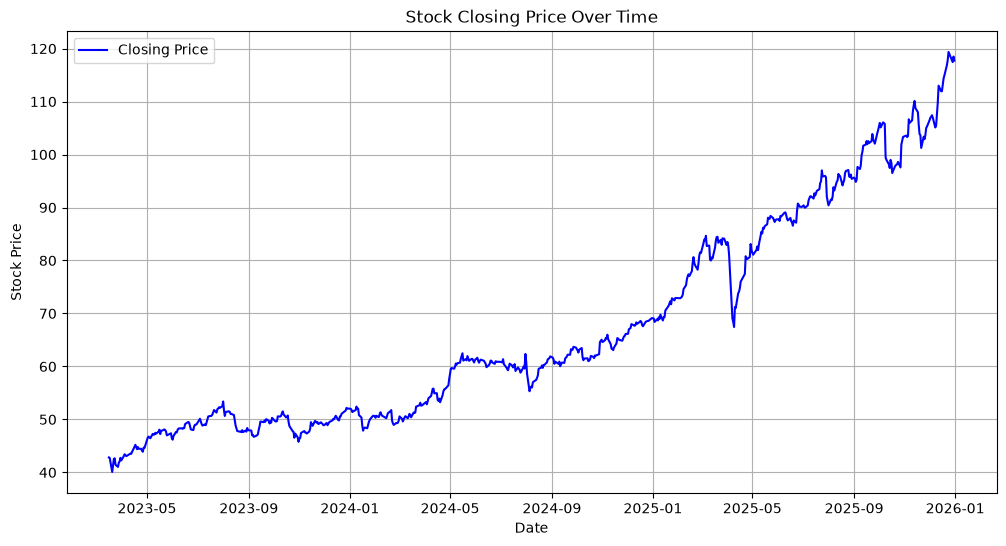

In [18]:
# EDA - explore trends and patterns
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

7-day MA captures short-term fluctuations while the 50-day MA provides a smoother long-term trend

Sharp deviations between moving averages may indicate trend reversals

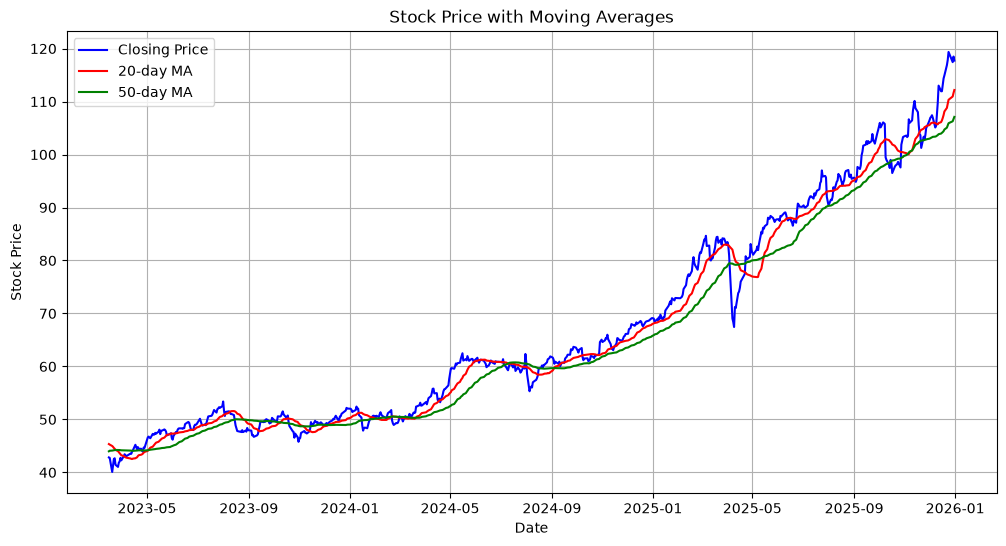

In [19]:
# Smoothen short-term fluctuations with moving averages
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['20-day MA'], label="20-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


Large spikes indicate high volatility days

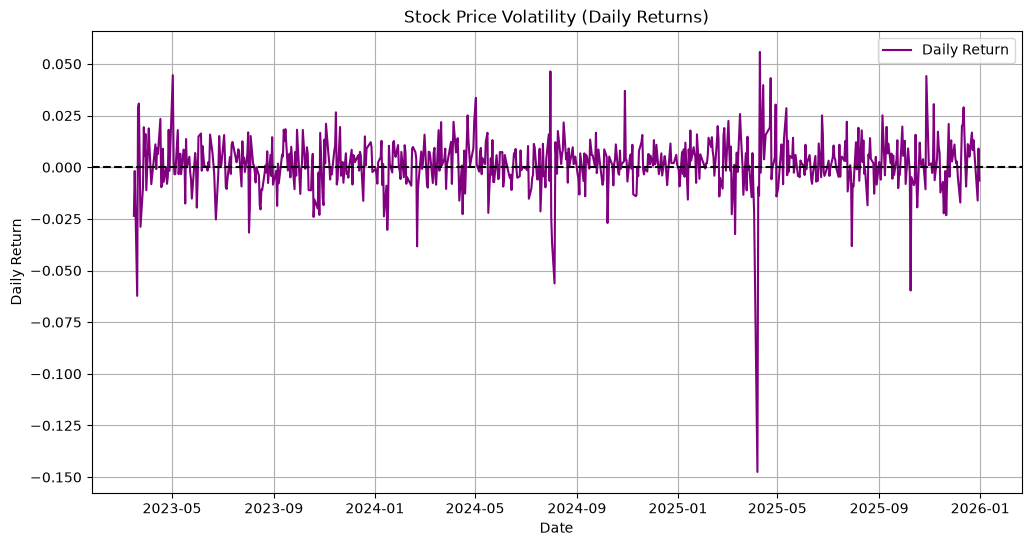

In [20]:
# Analyse Volatility
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# Normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [22]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: 1.7834511204285222
p-value: 0.9983156240298061
The series is not stationary.


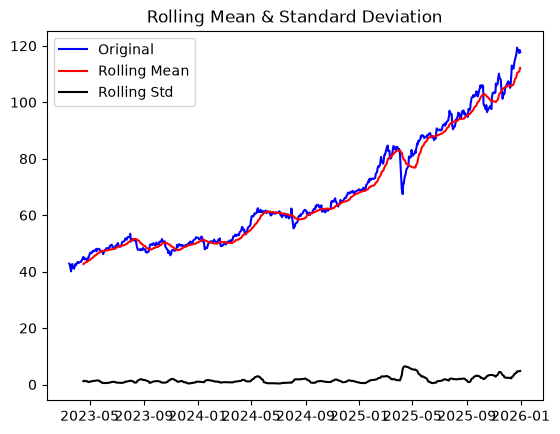

Results of Dickey-Fuller Test:
Test Statistic                   1.783451
p-value                          0.998316
#Lags Used                      14.000000
Number of Observations Used    671.000000
Critical Value (1%)             -3.440133
Critical Value (5%)             -2.865857
Critical Value (10%)            -2.569069
dtype: float64


In [23]:
#... LSTM - test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

The p-value is greater than the 5% critical value, so the null hypothesis cannot be rejected.

Regarding the test statistic used in the augmented Dickey-Tuller statistic, it is a negative number. The more negative it is, the stronger the rejection of the hypothesis that there is a unit root at some level of confidence.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

<Figure size 640x480 with 0 Axes>

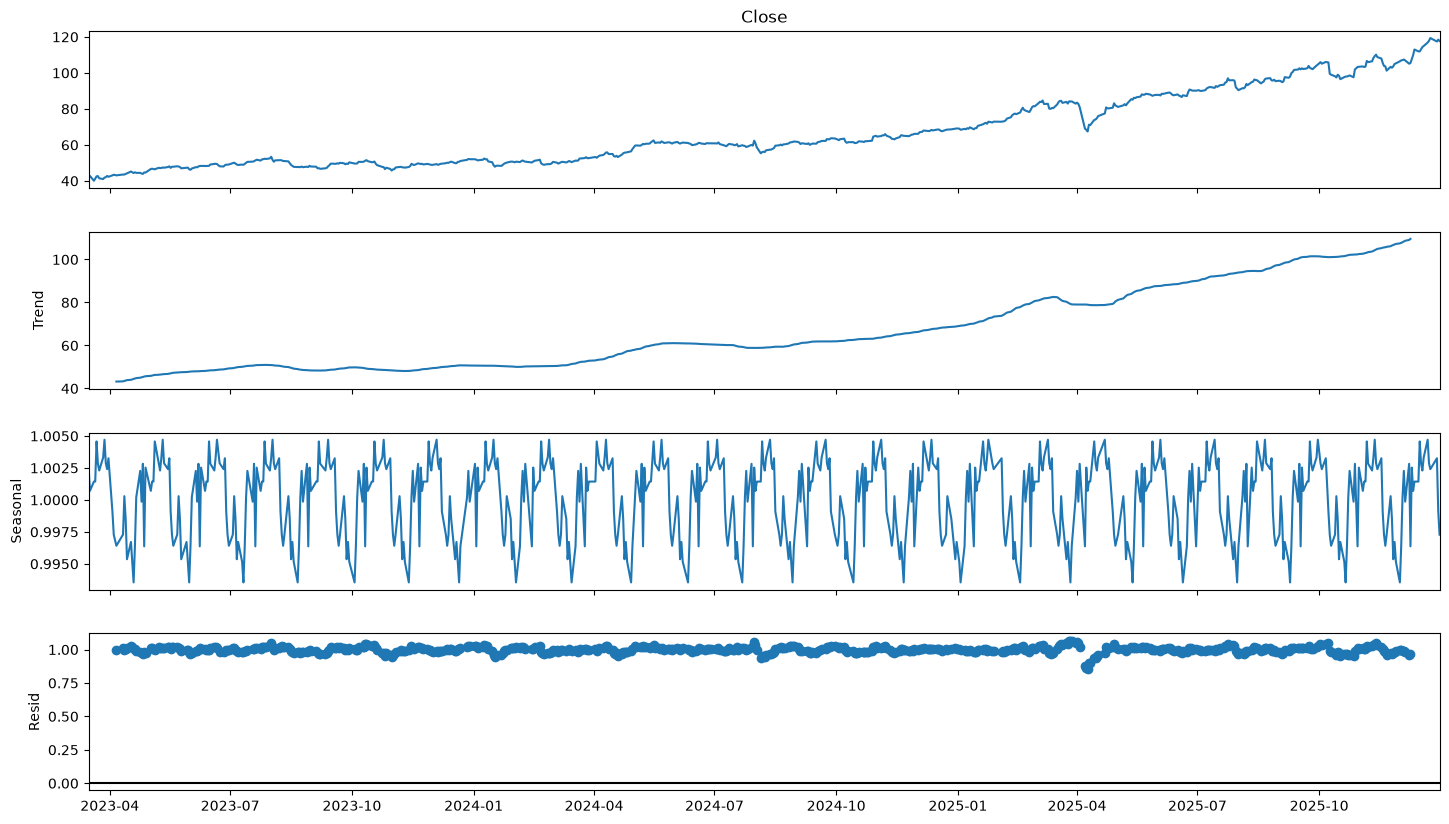

In [24]:
#...
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

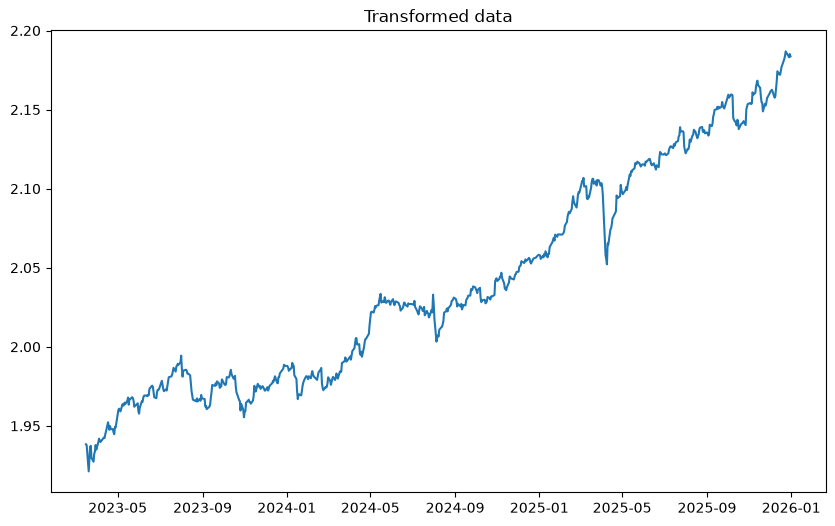

In [25]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

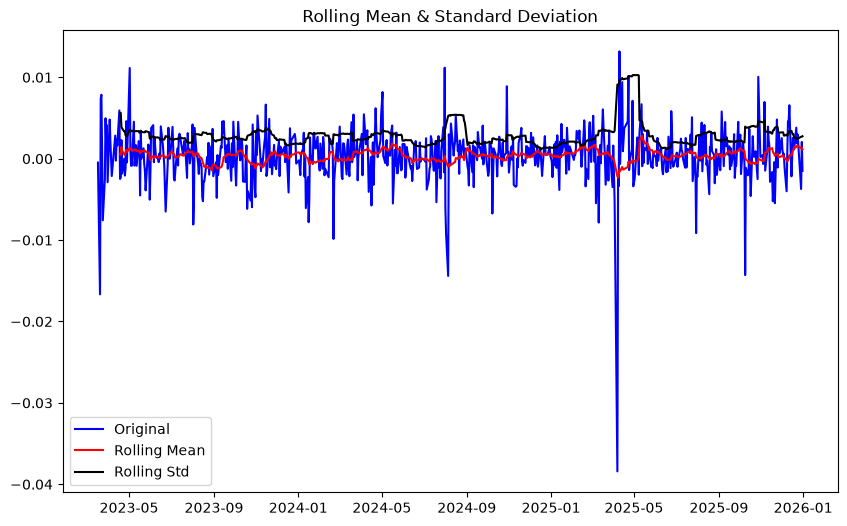

Results of Dickey-Fuller Test:
Test Statistic                -1.560948e+01
p-value                        1.787328e-28
#Lags Used                     2.000000e+00
Number of Observations Used    6.820000e+02
Critical Value (1%)           -3.439975e+00
Critical Value (5%)           -2.865787e+00
Critical Value (10%)          -2.569032e+00
dtype: float64


In [26]:
#... clssical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [27]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

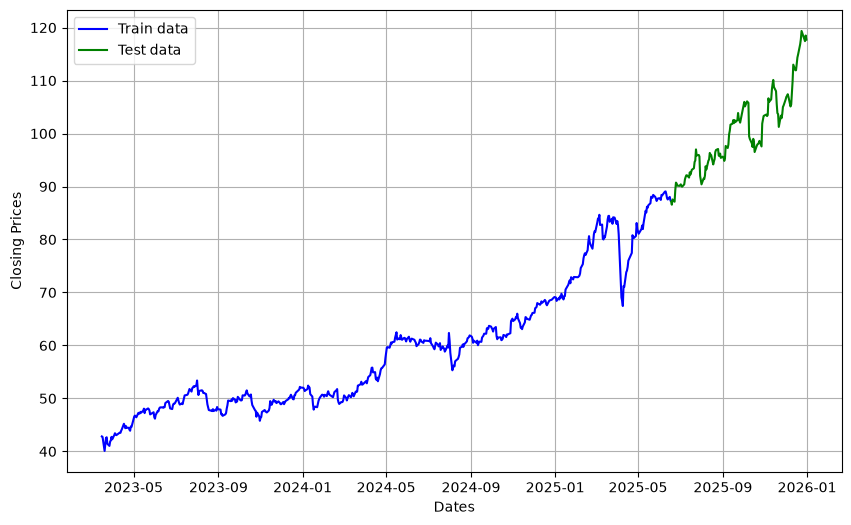

In [28]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [29]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 3.2257e-05 - mean_absolute_error: 0.0045
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.4203e-05 - mean_absolute_error: 0.0026
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.2545e-05 - mean_absolute_error: 0.0024
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.1766e-05 - mean_absolute_error: 0.0022
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.1363e-05 - mean_absolute_error: 0.0022
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.1574e-05 - mean_absolute_error: 0.0022
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.1404e-05 - mean_absolute_error: 0.0022
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.1181e-05 - mean_absolute_error: 0.0022
Epoch 9/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.1106e-05 - mean_absolute_error: 0.0022
Epoch 10/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.1015e-05 - mean_absolute_error: 0.0021

In [31]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.5910e-06 - mean_absolute_error: 0.0021
Test MSE: 8.590985999035183e-06
Test MAE: 0.002086375840008259


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


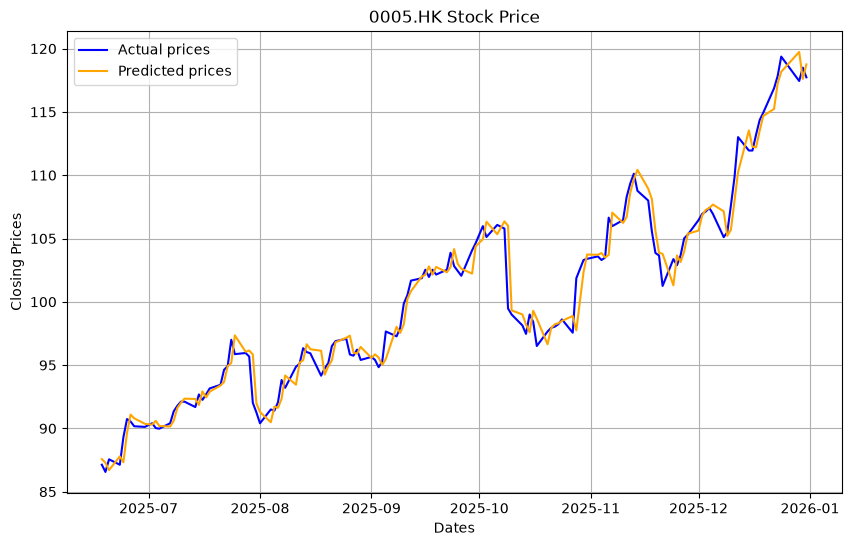

In [32]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

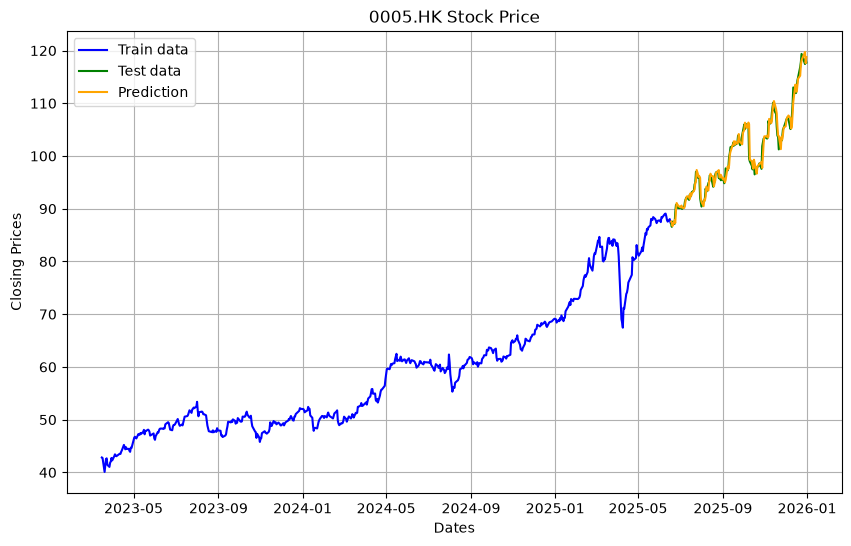

In [33]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [34]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
n_steps_out = 10

# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [35]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 1.5174e-05 - mean_absolute_error: 0.0027
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.2468e-05 - mean_absolute_error: 0.0024
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.2063e-05 - mean_absolute_error: 0.0023
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 1.2254e-05 - mean_absolute_error: 0.0023
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 1.2348e-05 - mean_absolute_error: 0.0023
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.2803e-05 - mean_absolute_error: 0.0024
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 1.1929e-05 - mean_absolute_error: 0.0023
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.1722e-05 - mean_absolute_error: 0.0022
Epoch 9/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 1.1999e-05 - mean_absolute_error: 0.0023
Epoch 10/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.1679e-05 - mean_absolute_error: 0.0022

In [37]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.0275e-06 - mean_absolute_error: 0.0022
Test MSE: 9.027540727402084e-06
Test MAE: 0.002162637421861291


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


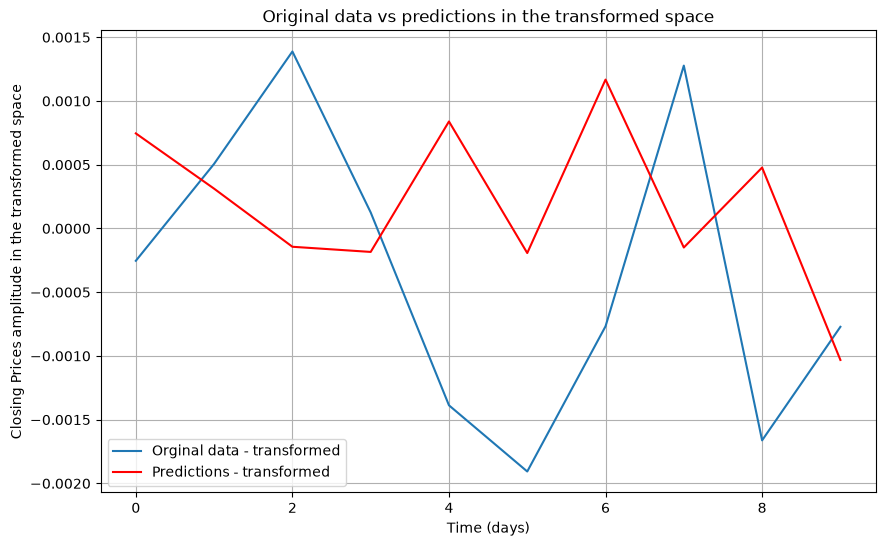

In [38]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [39]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-06-18    2.146377
2025-06-19    2.146689
2025-06-20    2.146546
2025-06-23    2.146362
2025-06-24    2.147201
2025-06-25    2.147008
2025-06-26    2.148176
2025-06-27    2.148026
2025-06-30    2.148504
2025-07-02    2.147472
dtype: float64


In [40]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-06-18    100.176652
2025-06-19    100.310935
2025-06-20    100.249102
2025-06-23    100.169897
2025-06-24    100.531510
2025-06-25    100.448267
2025-06-26    100.953366
2025-06-27    100.888589
2025-06-30    101.095921
2025-07-02    100.648883
dtype: float64


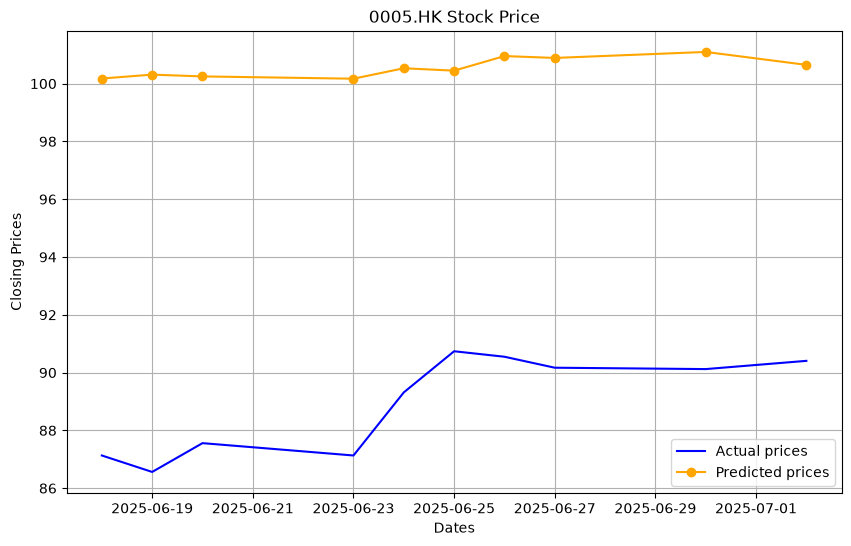

In [41]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [42]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     13.28
Date:                Fri, 25 Sep 2026   Prob (F-statistic):            0.00655
Time:                        16:08:08   Log-Likelihood:                 2.0799
No. Observations:                  10   AIC:                           -0.1598
Df Residuals:                       8   BIC:                            0.4454
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.3322      3.902     22.127      0.0

In [43]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Replace these arrays with your actual test data and model predictions
# Example: y_true (actual market prices), y_pred (your LSTM or ARIMA predictions)
#y_true = np.array([100.0, 102.5, 101.2, 105.0, 107.8])
#y_pred = np.array([101.2, 101.0, 102.0, 104.5, 109.1])

# 2. Calculate Standard Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"R² Score (Goodness of Fit):     {r2:.4f}")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      11.5786
Mean Squared Error (MSE):       135.8747
Root Mean Squared Error (RMSE): 11.6565
Mean Absolute Pct Error (MAPE): 13.05%
R² Score (Goodness of Fit):     -53.1064
Directional Accuracy (DA):      33.33%


In [51]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [52]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [53]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [47]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=30, batch_size=32)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0348
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.2593e-04
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0905e-04
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.9558e-04
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6852e-04
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6709e-04
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4930e-04
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.1927e-04
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2189e-04
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4177e-04
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.9441e-04
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.0833e-04
Epoch 15/30
17/17 ━━━━━━━━━

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [54]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=30, batch_size=32)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0276
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0052
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0021
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0016
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0015
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0017
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0013
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0013
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0012
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0011
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0012
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0012
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0012
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0012
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0011
Epoc

In [55]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


In [56]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.04563721925136156


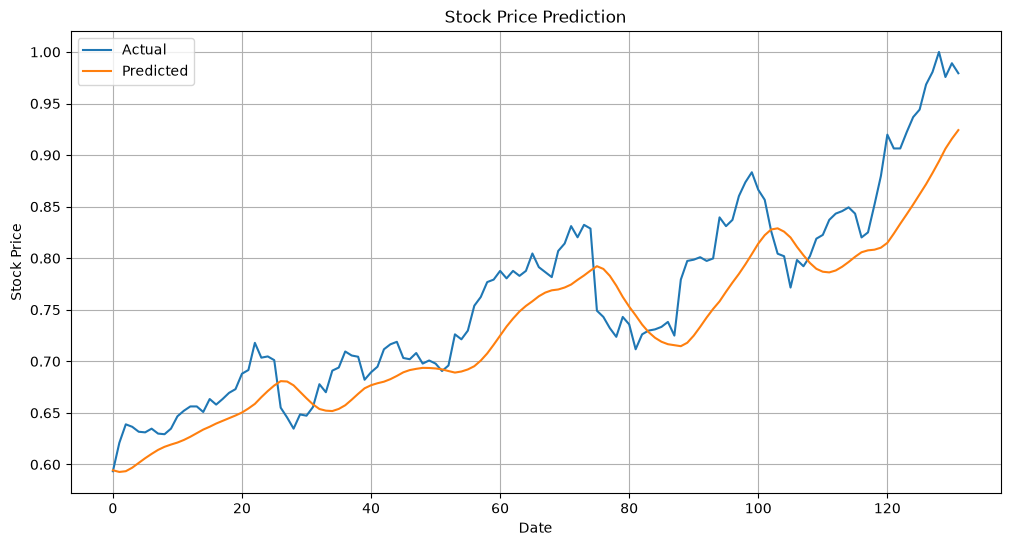

In [57]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

LSTMs are effective for stock price forecasting, capturing long-term dependencies better than traditional models. However, they struggle with extreme volatility and sudden market shifts.

Ways to Improve the Model:
🔹 Enhance feature selection — Incorporate trading volume, macroeconomic indicators (inflation, interest rates), and sentiment analysis from news & social media.
🔹 Experiment with advanced architectures — Try Transformer-based models (e.g., BERT, GPT for Finance) for better sequential understanding.
🔹 Hybrid models — Combine LSTMs with traditional time-series models (ARIMA + LSTM) for a more robust approach.

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.